# Preprocesamiento y Análisis Exploratorio — Dataset de Fraude Financiero

**Auditoría técnica — CONFAMA**

Punto de partida del análisis. Antes de cualquier modelo hay que entender qué tiene el dataset, qué le falta y qué nos dice por sí solo. Este notebook cubre la limpieza, la construcción de features y el EDA inicial.

Dataset: 50,000 transacciones, 9 columnas originales, ~1.5% de fraude etiquetado.


In [5]:
# ── Instalar dependencias ──────────────────────────────────────────────────────
!pip install pandas numpy matplotlib seaborn --quiet

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0F172A',
    'axes.facecolor':   '#1E293B',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94A3B8',
    'xtick.color':      '#94A3B8',
    'ytick.color':      '#94A3B8',
    'text.color':       '#F1F5F9',
    'grid.color':       '#1E293B',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
})
ROJO   = '#EF4444'
VERDE  = '#22C55E'
AZUL   = '#3B82F6'
AMBER  = '#F59E0B'
print('✅ Librerías importadas')

✅ Librerías importadas


## Carga del dataset

Dos opciones de carga; en Colab lo más práctico es subir el archivo directamente. Si ya se tiene montado Drive se puede usar la opción B para no tener que subir cada vez.


In [7]:
# ── OPCIÓN B: montar Google Drive ─────────────────────────────────────────────

CSV_PATH = '/content/drive/MyDrive/Ejercicio Fraude.csv'
df_raw = pd.read_csv(CSV_PATH)
print(f'✅ Cargado desde Drive: {df_raw.shape}')

✅ Cargado desde Drive: (50000, 9)


## 1. Inspección inicial

Lo primero es ver con qué trabajamos: dimensiones, tipos de cada columna, primeras filas y —crítico en fraude— cuántos nulos hay y cómo está distribuido el target. Con datasets desbalanceados un simple `.value_counts()` ya dice mucho sobre la dificultad del problema.


In [8]:
print('=== SHAPE ===')
print(df_raw.shape)

print('\n=== TIPOS ===')
print(df_raw.dtypes)

print('\n=== PRIMERAS FILAS ===')
df_raw.head()

=== SHAPE ===
(50000, 9)

=== TIPOS ===
id_transaccion            object
timestamp                 object
monto                    float64
categoria_comercio        object
tipo_tarjeta              object
score_dispositivo        float64
intentos_fallidos_24h      int64
pais_coincide              int64
target                     int64
dtype: object

=== PRIMERAS FILAS ===


,id_transaccion,timestamp,monto,categoria_comercio,tipo_tarjeta,score_dispositivo,intentos_fallidos_24h,pais_coincide,target
0,TX_033554,2026-02-25 10:21:49,40.23,Viajes,Crédito,82.1,1,1,0
1,TX_009428,2026-01-10 16:12:56,10.22,Servicios,Crédito,86.3,0,1,0
2,TX_000200,2026-02-19 04:40:35,439.19,Entretenimiento,Débito,86.9,0,1,0
3,TX_012448,2026-02-17 00:45:44,12.37,Servicios,Crédito,92.5,1,1,0
4,TX_039490,2026-01-07 21:30:33,43.09,Retail,Débito,90.0,0,1,0


In [9]:
print('=== NULOS POR COLUMNA ===')
nulos = df_raw.isnull().sum()
print(nulos[nulos > 0])

print(f'\nDistribución de target:')
vc = df_raw['target'].value_counts()
print(vc)
print(f'Tasa de fraude: {vc[1]/len(df_raw)*100:.2f}%')

=== NULOS POR COLUMNA ===
score_dispositivo    1172
dtype: int64

Distribución de target:
target
0    49250
1      750
Name: count, dtype: int64
Tasa de fraude: 1.50%


## 2. Preprocesamiento y construcción de features

El dataset original solo tiene `timestamp` como información temporal; hay que descomponerlo en señales útiles.

**¿Por qué estas features temporales?**  
El fraude con tarjeta tiene un patrón horario conocido: la madrugada concentra transacciones de tarjetas robadas porque el titular está durmiendo y no recibe alertas. `es_hora_riesgo` captura eso con un flag binario en vez de dejar que el modelo infiera la curva no lineal por sí solo. `dia_semana` y `es_fin_semana` ayudan porque los equipos de fraude tienen menor cobertura en horario reducido.

**¿Por qué `monto_log`?**  
La distribución de montos es muy sesgada a la derecha (algunos fraudes de ticket muy alto). El logaritmo comprime esa cola y estabiliza la varianza, lo que mejora la convergencia de los modelos basados en distancias y facilita la visualización.


In [10]:
df = df_raw.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Features temporales
df['hora']          = df['timestamp'].dt.hour
df['dia_semana']    = df['timestamp'].dt.dayofweek
df['mes']           = df['timestamp'].dt.month
df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)
df['es_hora_riesgo'] = ((df['hora'] >= 23) | (df['hora'] <= 5)).astype(int)

# Transformación logarítmica del monto
df['monto_log'] = np.log1p(df['monto'])

print('Features creados:', ['hora','dia_semana','mes','es_fin_semana','es_hora_riesgo','monto_log'])
print(df[['hora','dia_semana','mes','es_fin_semana','es_hora_riesgo','monto_log']].head())

Features creados: ['hora', 'dia_semana', 'mes', 'es_fin_semana', 'es_hora_riesgo', 'monto_log']
   hora  dia_semana  mes  es_fin_semana  es_hora_riesgo  monto_log
0    10           2    2              0               0   3.719166
1    16           5    1              1               0   2.417698
2     4           3    2              0               1   6.087206
3     0           1    2              0               1   2.593013
4    21           2    1              0               0   3.786233


In [11]:
# Imputación estratificada de score_dispositivo
# Agrupamos por (pais_coincide × categoria_comercio) y usamos la mediana de cada grupo

nulos_antes = df['score_dispositivo'].isna().sum()
print(f'Nulos antes de imputar: {nulos_antes}')

grupo_medianas = df.groupby(['pais_coincide', 'categoria_comercio'])['score_dispositivo'].median()

for (pais, cat), mediana in grupo_medianas.items():
    if pd.isna(mediana):
        continue
    mask = (df['pais_coincide'] == pais) & (df['categoria_comercio'] == cat) & df['score_dispositivo'].isna()
    df.loc[mask, 'score_dispositivo'] = mediana

# Fallback: mediana global
if df['score_dispositivo'].isna().any():
    mediana_global = df['score_dispositivo'].median()
    df['score_dispositivo'] = df['score_dispositivo'].fillna(mediana_global)

nulos_despues = df['score_dispositivo'].isna().sum()
print(f'Nulos después de imputar: {nulos_despues}')
print(f'\nEstadísticas score_dispositivo post-imputación:')
print(df['score_dispositivo'].describe().round(2))

Nulos antes de imputar: 1172
Nulos después de imputar: 0

Estadísticas score_dispositivo post-imputación:
count    50000.00
mean        84.26
std          9.63
min          0.00
25%         79.60
50%         84.90
75%         90.10
max        100.00
Name: score_dispositivo, dtype: float64


## 3. Análisis exploratorio

Antes de modelar necesitamos saber qué variables discriminan fraude de transacción legítima. El EDA guía la ingeniería de features y da intuición para interpretar luego los modelos.

Los análisis están ordenados por poder discriminante esperado: primero las variables que intuitivamente deberían importar (hora, categoría, país), luego correlaciones globales para ver si hay multicolinealidad relevante.


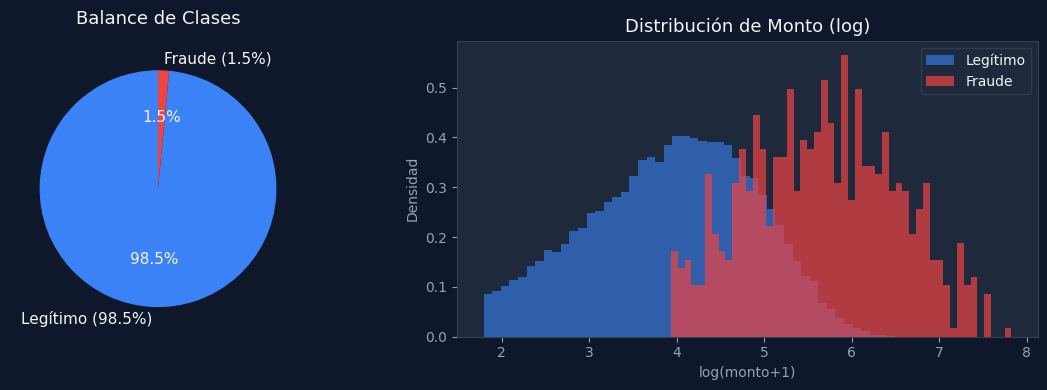

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0F172A')

# Balance de clases
labels = ['Legítimo (98.5%)', 'Fraude (1.5%)']
sizes  = [df['target'].eq(0).sum(), df['target'].eq(1).sum()]
colors = [AZUL, ROJO]
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            textprops={'color':'#F1F5F9','fontsize':11}, startangle=90)
axes[0].set_title('Balance de Clases', color='#F1F5F9', fontsize=13, pad=12)

# Distribución de monto (log)
legit  = df[df['target']==0]['monto_log']
fraude = df[df['target']==1]['monto_log']
axes[1].hist(legit,  bins=50, alpha=0.6, color=AZUL, label='Legítimo',  density=True)
axes[1].hist(fraude, bins=50, alpha=0.7, color=ROJO,  label='Fraude',   density=True)
axes[1].set_xlabel('log(monto+1)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de Monto (log)', color='#F1F5F9', fontsize=13)
axes[1].legend(facecolor='#1E293B', edgecolor='#334155')

plt.tight_layout()
plt.show()

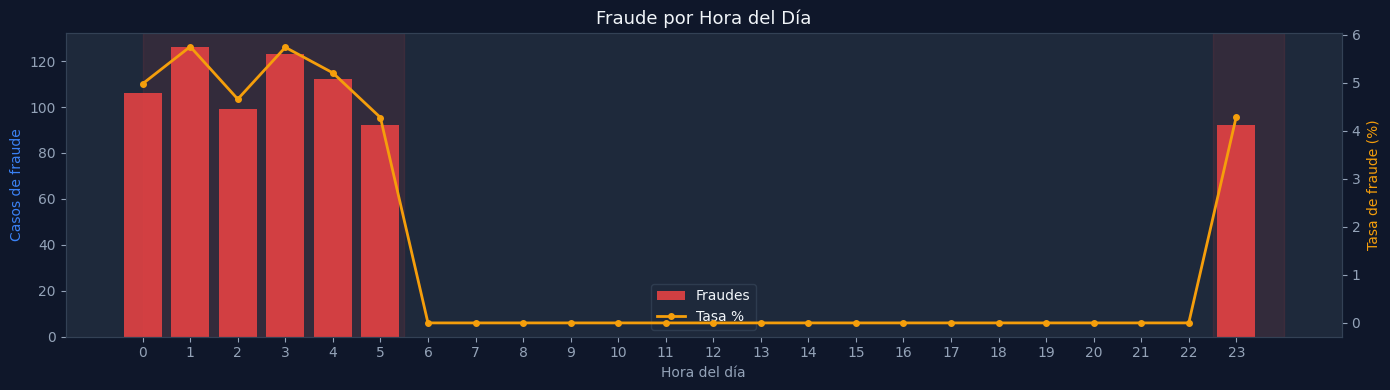

🔴 Zona de riesgo: 23h–5h
Fraudes en zona riesgo: 750 (100.0% del total)


In [13]:
fraude_hora = df.groupby('hora').agg(
    total=('target','count'),
    fraudes=('target','sum')
).reset_index()
fraude_hora['tasa'] = fraude_hora['fraudes'] / fraude_hora['total'] * 100

fig, ax1 = plt.subplots(figsize=(14, 4), facecolor='#0F172A')
ax2 = ax1.twinx()

colores = [ROJO if (h >= 23 or h <= 5) else AZUL for h in fraude_hora['hora']]
ax1.bar(fraude_hora['hora'], fraude_hora['fraudes'], color=colores, alpha=0.85, label='Fraudes')
ax2.plot(fraude_hora['hora'], fraude_hora['tasa'], color=AMBER, linewidth=2, marker='o', markersize=4, label='Tasa %')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Casos de fraude', color=AZUL)
ax2.set_ylabel('Tasa de fraude (%)', color=AMBER)
ax1.set_title('Fraude por Hora del Día', color='#F1F5F9', fontsize=13)
ax1.set_xticks(range(24))
ax1.axvspan(22.5, 24, alpha=0.1, color=ROJO)
ax1.axvspan(0, 5.5, alpha=0.1, color=ROJO)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, facecolor='#1E293B', edgecolor='#334155')
plt.tight_layout()
plt.show()

print('🔴 Zona de riesgo: 23h–5h')
hr = fraude_hora[fraude_hora['hora'].isin(list(range(23,24))+list(range(0,6)))]
print(f'Fraudes en zona riesgo: {hr["fraudes"].sum()} ({hr["fraudes"].sum()/fraude_hora["fraudes"].sum()*100:.1f}% del total)')

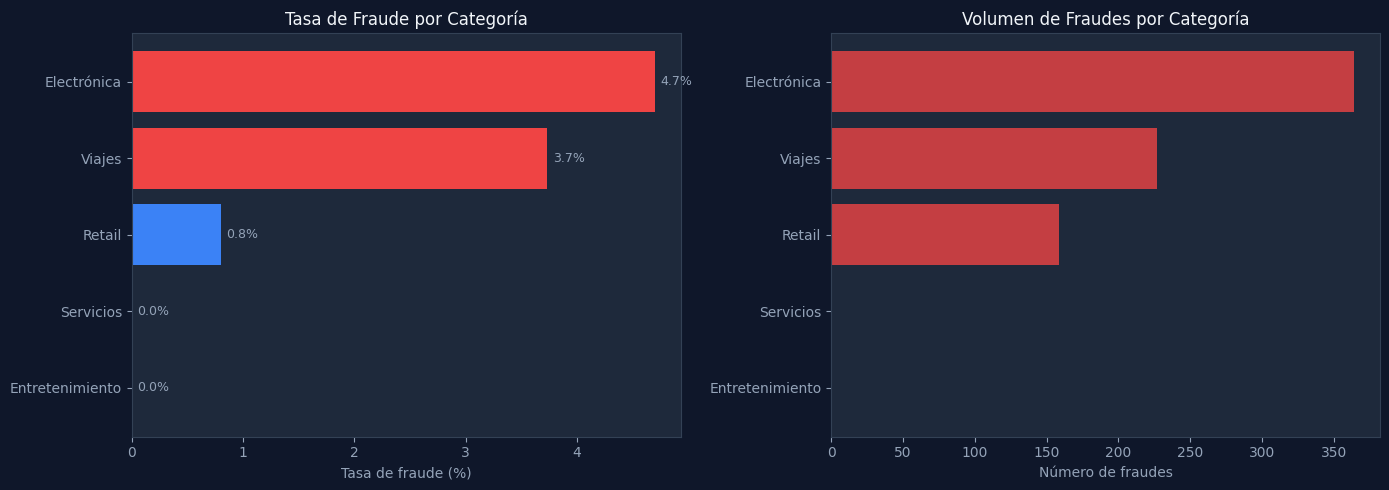

In [14]:
fraude_cat = df.groupby('categoria_comercio').agg(
    total=('target','count'),
    fraudes=('target','sum')
).reset_index()
fraude_cat['tasa'] = fraude_cat['fraudes'] / fraude_cat['total'] * 100
fraude_cat = fraude_cat.sort_values('tasa', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0F172A')

# Tasa de fraude
bars = axes[0].barh(fraude_cat['categoria_comercio'], fraude_cat['tasa'],
                    color=[ROJO if t > fraude_cat['tasa'].median() else AZUL for t in fraude_cat['tasa']])
axes[0].set_xlabel('Tasa de fraude (%)')
axes[0].set_title('Tasa de Fraude por Categoría', color='#F1F5F9', fontsize=12)
for bar, val in zip(bars, fraude_cat['tasa']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, color='#94A3B8')

# Volumen de fraudes
fraude_cat_sorted = fraude_cat.sort_values('fraudes', ascending=True)
axes[1].barh(fraude_cat_sorted['categoria_comercio'], fraude_cat_sorted['fraudes'], color=ROJO, alpha=0.8)
axes[1].set_xlabel('Número de fraudes')
axes[1].set_title('Volumen de Fraudes por Categoría', color='#F1F5F9', fontsize=12)

plt.tight_layout()
plt.show()

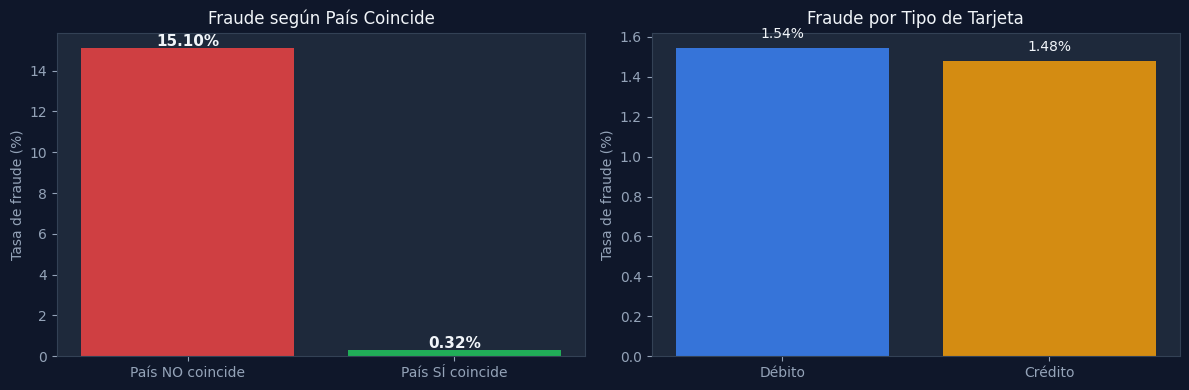

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0F172A')

# Pais coincide
pais_data = df.groupby('pais_coincide')['target'].agg(['sum','count'])
pais_data['tasa'] = pais_data['sum'] / pais_data['count'] * 100
pais_labels = ['País NO coincide', 'País SÍ coincide']
axes[0].bar(pais_labels, pais_data['tasa'], color=[ROJO, VERDE], alpha=0.85)
axes[0].set_ylabel('Tasa de fraude (%)')
axes[0].set_title('Fraude según País Coincide', color='#F1F5F9', fontsize=12)
for i, v in enumerate(pais_data['tasa']):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=11, fontweight='bold')

# Tipo de tarjeta
tarj_data = df.groupby('tipo_tarjeta')['target'].agg(['sum','count'])
tarj_data['tasa'] = tarj_data['sum'] / tarj_data['count'] * 100
tarj_data = tarj_data.sort_values('tasa', ascending=False)
axes[1].bar(tarj_data.index, tarj_data['tasa'],
            color=[AZUL, AMBER, ROJO, VERDE][:len(tarj_data)], alpha=0.85)
axes[1].set_ylabel('Tasa de fraude (%)')
axes[1].set_title('Fraude por Tipo de Tarjeta', color='#F1F5F9', fontsize=12)
for i, (idx, row) in enumerate(tarj_data.iterrows()):
    axes[1].text(i, row['tasa'] + 0.05, f'{row["tasa"]:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

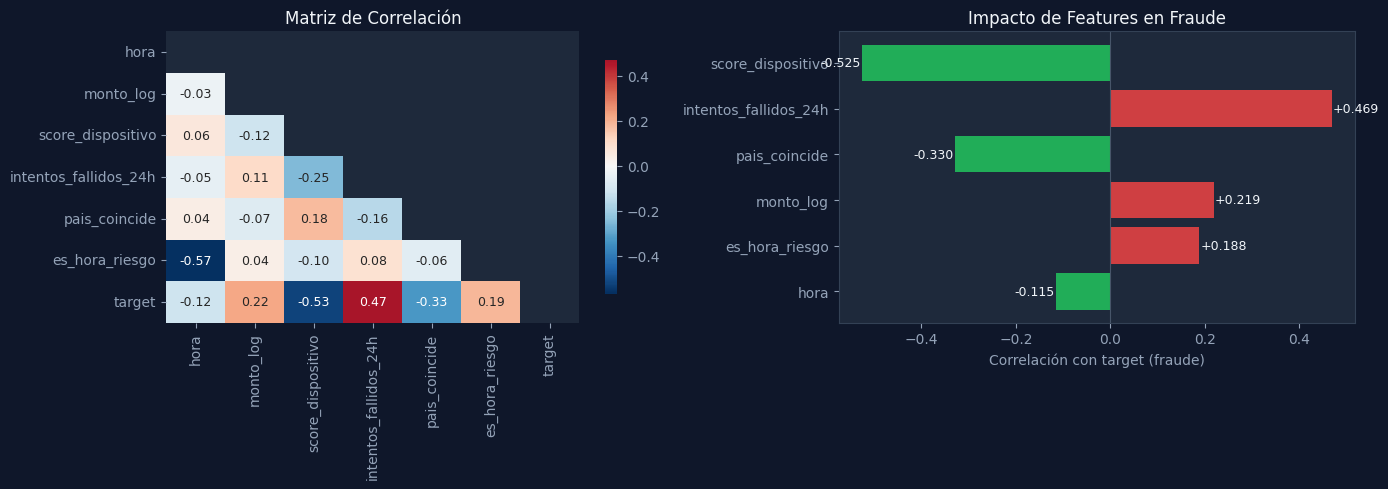

In [16]:
num_cols = ['hora','monto_log','score_dispositivo','intentos_fallidos_24h',
            'pais_coincide','es_hora_riesgo','target']
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0F172A')

# Heatmap de correlación
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0],
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
axes[0].set_title('Matriz de Correlación', color='#F1F5F9', fontsize=12)

# Correlación con target (barras)
corr_target = corr['target'].drop('target').sort_values(key=abs, ascending=True)
colors_corr = [ROJO if v > 0 else VERDE for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors_corr, alpha=0.85)
axes[1].axvline(0, color='#475569', linewidth=0.8)
axes[1].set_xlabel('Correlación con target (fraude)')
axes[1].set_title('Impacto de Features en Fraude', color='#F1F5F9', fontsize=12)
for i, (v, feat) in enumerate(zip(corr_target.values, corr_target.index)):
    axes[1].text(v + (0.002 if v >= 0 else -0.002), i, f'{v:+.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

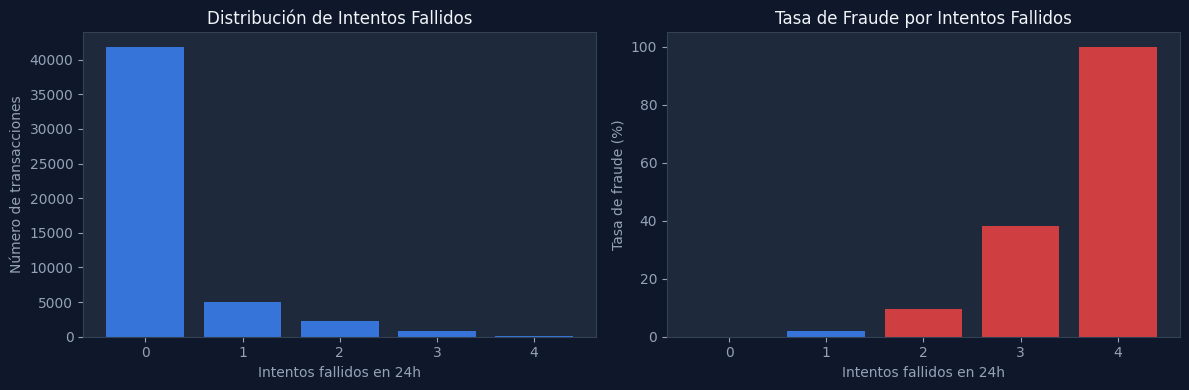

📊 Insight: con ≥3 intentos fallidos la tasa de fraude aumenta dramáticamente


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0F172A')

# Distribución de intentos fallidos
intentos_dist = df['intentos_fallidos_24h'].value_counts().sort_index()
axes[0].bar(intentos_dist.index, intentos_dist.values, color=AZUL, alpha=0.85)
axes[0].set_xlabel('Intentos fallidos en 24h')
axes[0].set_ylabel('Número de transacciones')
axes[0].set_title('Distribución de Intentos Fallidos', color='#F1F5F9', fontsize=12)

# Tasa de fraude por número de intentos
tasa_intentos = df.groupby('intentos_fallidos_24h')['target'].mean() * 100
axes[1].bar(tasa_intentos.index, tasa_intentos.values,
            color=[ROJO if v > 2 else AZUL for v in tasa_intentos.values], alpha=0.85)
axes[1].set_xlabel('Intentos fallidos en 24h')
axes[1].set_ylabel('Tasa de fraude (%)')
axes[1].set_title('Tasa de Fraude por Intentos Fallidos', color='#F1F5F9', fontsize=12)

plt.tight_layout()
plt.show()

print('📊 Insight: con ≥3 intentos fallidos la tasa de fraude aumenta dramáticamente')

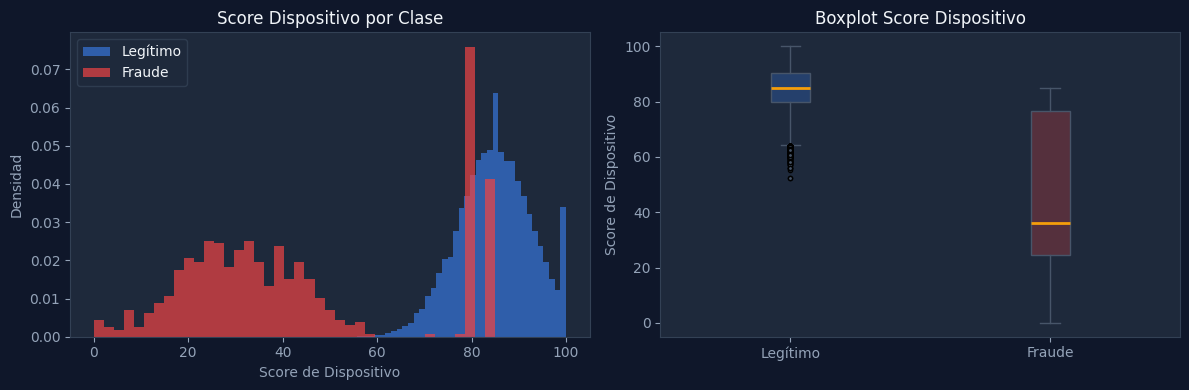

Mediana legítimo:  84.90
Mediana fraude:    36.05


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0F172A')

# Distribución score_dispositivo por clase
legit_score  = df[df['target']==0]['score_dispositivo']
fraude_score = df[df['target']==1]['score_dispositivo']
axes[0].hist(legit_score,  bins=40, alpha=0.6, color=AZUL,  label='Legítimo', density=True)
axes[0].hist(fraude_score, bins=40, alpha=0.7, color=ROJO,   label='Fraude',  density=True)
axes[0].set_xlabel('Score de Dispositivo')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Score Dispositivo por Clase', color='#F1F5F9', fontsize=12)
axes[0].legend(facecolor='#1E293B', edgecolor='#334155')

# Box plot
data_box = [legit_score, fraude_score]
bp = axes[1].boxplot(data_box, labels=['Legítimo','Fraude'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#1E293B', color='#475569'),
                     medianprops=dict(color=AMBER, linewidth=2),
                     whiskerprops=dict(color='#475569'),
                     capprops=dict(color='#475569'),
                     flierprops=dict(markerfacecolor='#475569', markersize=3))
bp['boxes'][0].set_facecolor(AZUL + '44')
bp['boxes'][1].set_facecolor(ROJO  + '44')
axes[1].set_ylabel('Score de Dispositivo')
axes[1].set_title('Boxplot Score Dispositivo', color='#F1F5F9', fontsize=12)

plt.tight_layout()
plt.show()

print(f'Mediana legítimo:  {legit_score.median():.2f}')
print(f'Mediana fraude:    {fraude_score.median():.2f}')

## 4. Resumen de hallazgos

Antes de pasar a los modelos: qué aprendimos del EDA y qué implica para el diseño del sistema.

El desbalance de clases (1.5%) es el dato más crítico operativamente. Usar accuracy como métrica sería un error porque un modelo que prediga siempre "legítimo" tendría 98.5% de accuracy sin detectar un solo fraude. Por eso en el Notebook 2 se usan F1, PR-AUC y se aplicará SMOTE solo en entrenamiento.


In [19]:
# Guardar df preprocesado para usar en el siguiente notebook
df.to_csv('df_preprocesado.csv', index=False)
print('✅ df_preprocesado.csv guardado — úsalo en el Notebook 2')

✅ df_preprocesado.csv guardado — úsalo en el Notebook 2
